In [1]:
import os
import cv2

# Path to the directory containing the images
directory_path = r'C:\Users\USER\Desktop\DeepLearning Project End_to_End\images'

# Loop through all the files in the directory
for filename in os.listdir(directory_path):
    # Check if the file is an image file
    if filename.endswith('.jpg') or filename.endswith('.png') or filename.endswith('.bmp'):
        # Load the image
        img = cv2.imread(os.path.join(directory_path, filename))

        # Convert the image to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Normalize the pixel values to range from 0 to 255
        normalized_gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)

        # Save the normalized image
        cv2.imwrite(os.path.join(directory_path, 'normalized_' + filename), normalized_gray)


In [2]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [11]:
IMAGE_SIZE = 600
IMAGE_SIZE1= 800
BATCH_SIZE = 16
EPOCHS =5
CHANNELS = 3

# Import data into tensorflow dataset object
# We will use image_dataset_from_directory api to load all images in tensorflow dataset: https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory

In [12]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
"images",
shuffle=True,
image_size=(IMAGE_SIZE,IMAGE_SIZE1),
    
batch_size= BATCH_SIZE
)

Found 2401 files belonging to 6 classes.


In [13]:
class_names =dataset.class_names
class_names

['180', '240', '320', '400', 'blank', 'reject']

In [14]:
len(dataset)

151

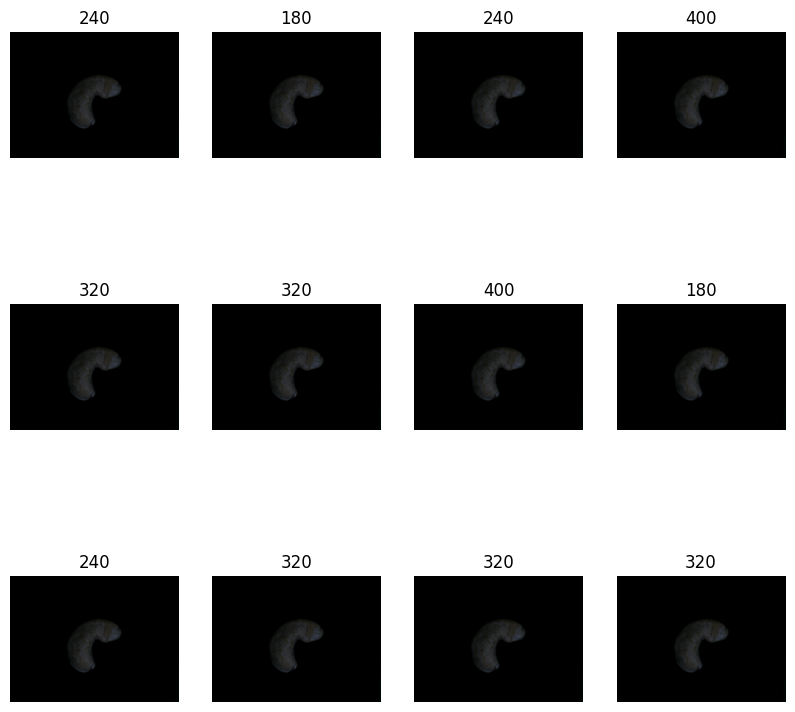

In [15]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[0].numpy().astype("uint8"))
        # As we dont want number in images
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

Function to Split Dataset
Dataset should be bifurcated into 3 subsets, namely:

Training: Dataset to be used while training

Validation: Dataset to be tested against while training

Test: Dataset to be tested against after we trained a model

In [16]:
len(dataset)

151

80% ==> training 
20% ==> 10% validation 10% testing 


In [17]:
train_size = 0.8
len(dataset)*train_size

120.80000000000001

In [18]:
train_ds = dataset.take(30)
len(train_ds)

30

In [19]:
test_ds = dataset.skip(30)
len(test_ds)

121

In [20]:
val_size = 0.1
len(dataset)*val_size

15.100000000000001

In [21]:
val_ds = test_ds.take(3)
len(val_ds)

3

In [22]:
test_ds = test_ds.skip(3)
len(test_ds)

118

In [23]:
def get_dataset_partitions_tf(ds,train_split=0.8,val_split=0.1,test_split=0.1,shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    
    
    if shuffle:
        ds = ds.shuffle(shuffle_size,seed = 12)
    
    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)
    
    train_ds = ds.take(train_size)
    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds,val_ds,test_ds

In [24]:
train_ds,val_ds,test_ds = get_dataset_partitions_tf(dataset)

In [25]:
len(train_ds)

120

In [26]:
len(val_ds)

15

In [27]:
len(test_ds)

16

# Cache, Shuffle, and Prefetch the Dataset

In [28]:
train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

# Building the Model
 - Creating a Layer for Resizing and Normalization
 - Before we feed our images to network, we should be resizing it to the desired size. Moreover, to improve model performance, we should normalize the image pixel value (keeping them in range 0 and 1 by dividing by 256). This should happen while training as well as inference. Hence we can add that as a layer in our Sequential Model.

- You might be thinking why do we need to resize (256,256) image to again (256,256). You are right we don't need to but this will be useful when we are done with the training and start using the model for predictions. At that time somone can supply an image that is not (256,256) and this layer will resize it

In [21]:
# preprocesiing pipeline

In [29]:
resize_and_rescale = tf.keras.Sequential([
    
    #rescalling bu api
    
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE,IMAGE_SIZE1),
    layers.experimental.preprocessing.Rescaling(1.0/255)
    
])

In [23]:
# images is taken zoom and more then we have to use data Augmentation 

# Data Augmentation
- Data Augmentation is needed when we have less data, this boosts the accuracy of our model by augmenting the data.





In [30]:
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2),
])

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

Watch below video if you are not familiar with data augmentation
https://www.youtube.com/embed/mTVf7BN7S8w

# Model Architecture
We use a CNN coupled with a Softmax activation in the output layer. We also add the initial layers for resizing, normalization and Data Augmentation.

We are going to use convolutional neural network (CNN) here. CNN is popular for image classification tasks. Watch below video to understand fundamentals of CNN

https://www.youtube.com/embed/zfiSAzpy9NM


# Deep CNN or Convolutional Neural Network



In [31]:
input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE1,CHANNELS)
n_classes = 6


model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3),activation='relu',input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
    
    
    
])



model.build(input_shape=input_shape)

In [32]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (16, 600, 800, 3)         0         
                                                                 
 sequential_1 (Sequential)   (16, 600, 800, 3)         0         
                                                                 
 conv2d (Conv2D)             (16, 598, 798, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (16, 299, 399, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (16, 297, 397, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (16, 148, 198, 64)       0         
 2D)                                                  

# Compiling the Model
- We use adam Optimizer, SparseCategoricalCrossentropy for losses, accuracy as a metric

In [35]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [36]:

history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS
)

Epoch 1/5


: 

: 

In [ ]:
scores = model.evaluate(test_ds)

In [ ]:
# You can see above that we get 76% accuracy for our test dataset. This is considered to be a pretty good accuracy

In [ ]:
scores

# Exporting an model into pickle format

# Plotting the Accuracy and Loss Curves

In [ ]:
history

# You can read documentation on history object here: https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/History

In [ ]:
history.params

In [ ]:
history.history.keys()

# loss, accuracy, val loss etc are a python list containing values of loss, accuracy etc at the end of each epoch

In [ ]:
type(history.history['loss'])

In [ ]:
len(history.history['loss'])

In [ ]:
history.history['loss'][:5] # show loss for first 5 epochs

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [ ]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Run prediction on a sample image

In [ ]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

# Write a function for inference

In [ ]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) # created a batch

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

# Now run inference on few sample images

In [ ]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

# Saving the Model
# We append the model to the list of models as a new version

In [ ]:
import os
model_version=max([int(i) for i in os.listdir("./saved_models") + [0]])+1
model.save(f"./saved_models/{model_version}")

In [ ]:
model.save("./AI_Model.model")

In [ ]:
# import pickle

# pickle.dump(history, open('saved_models/AI_Model.model', 'wb'))